# Extended Wigner's friend scenario (with GHZ friends)

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [51]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_distribution, plot_histogram

from ewfs import EWFS, decode_results, MAJORITY_VOTE, post_select_results
from ewfs.setting import PEEK, REVERSE_1, REVERSE_2
from ewfs.noise_models import depolarizing_model

## Sanity checks (for majority vote approach)

GHZ Circuit Layout:
[57, 0, 56, 58, 77, 38, 37, 59]


/Users/farrokhlabib/Documents/github/wigners_friend/.venv/lib/python3.12/site-packages/qiskit/visualization/circuit/matplotlib.py:270: UserWarning: Style JSON file 'default.json' not found in any of these locations: /Users/farrokhlabib/Documents/github/wigners_friend/.venv/lib/python3.12/site-packages/qiskit/visualization/circuit/styles/default.json, default.json. Will use default style.
  self._style, def_font_ratio = load_style(


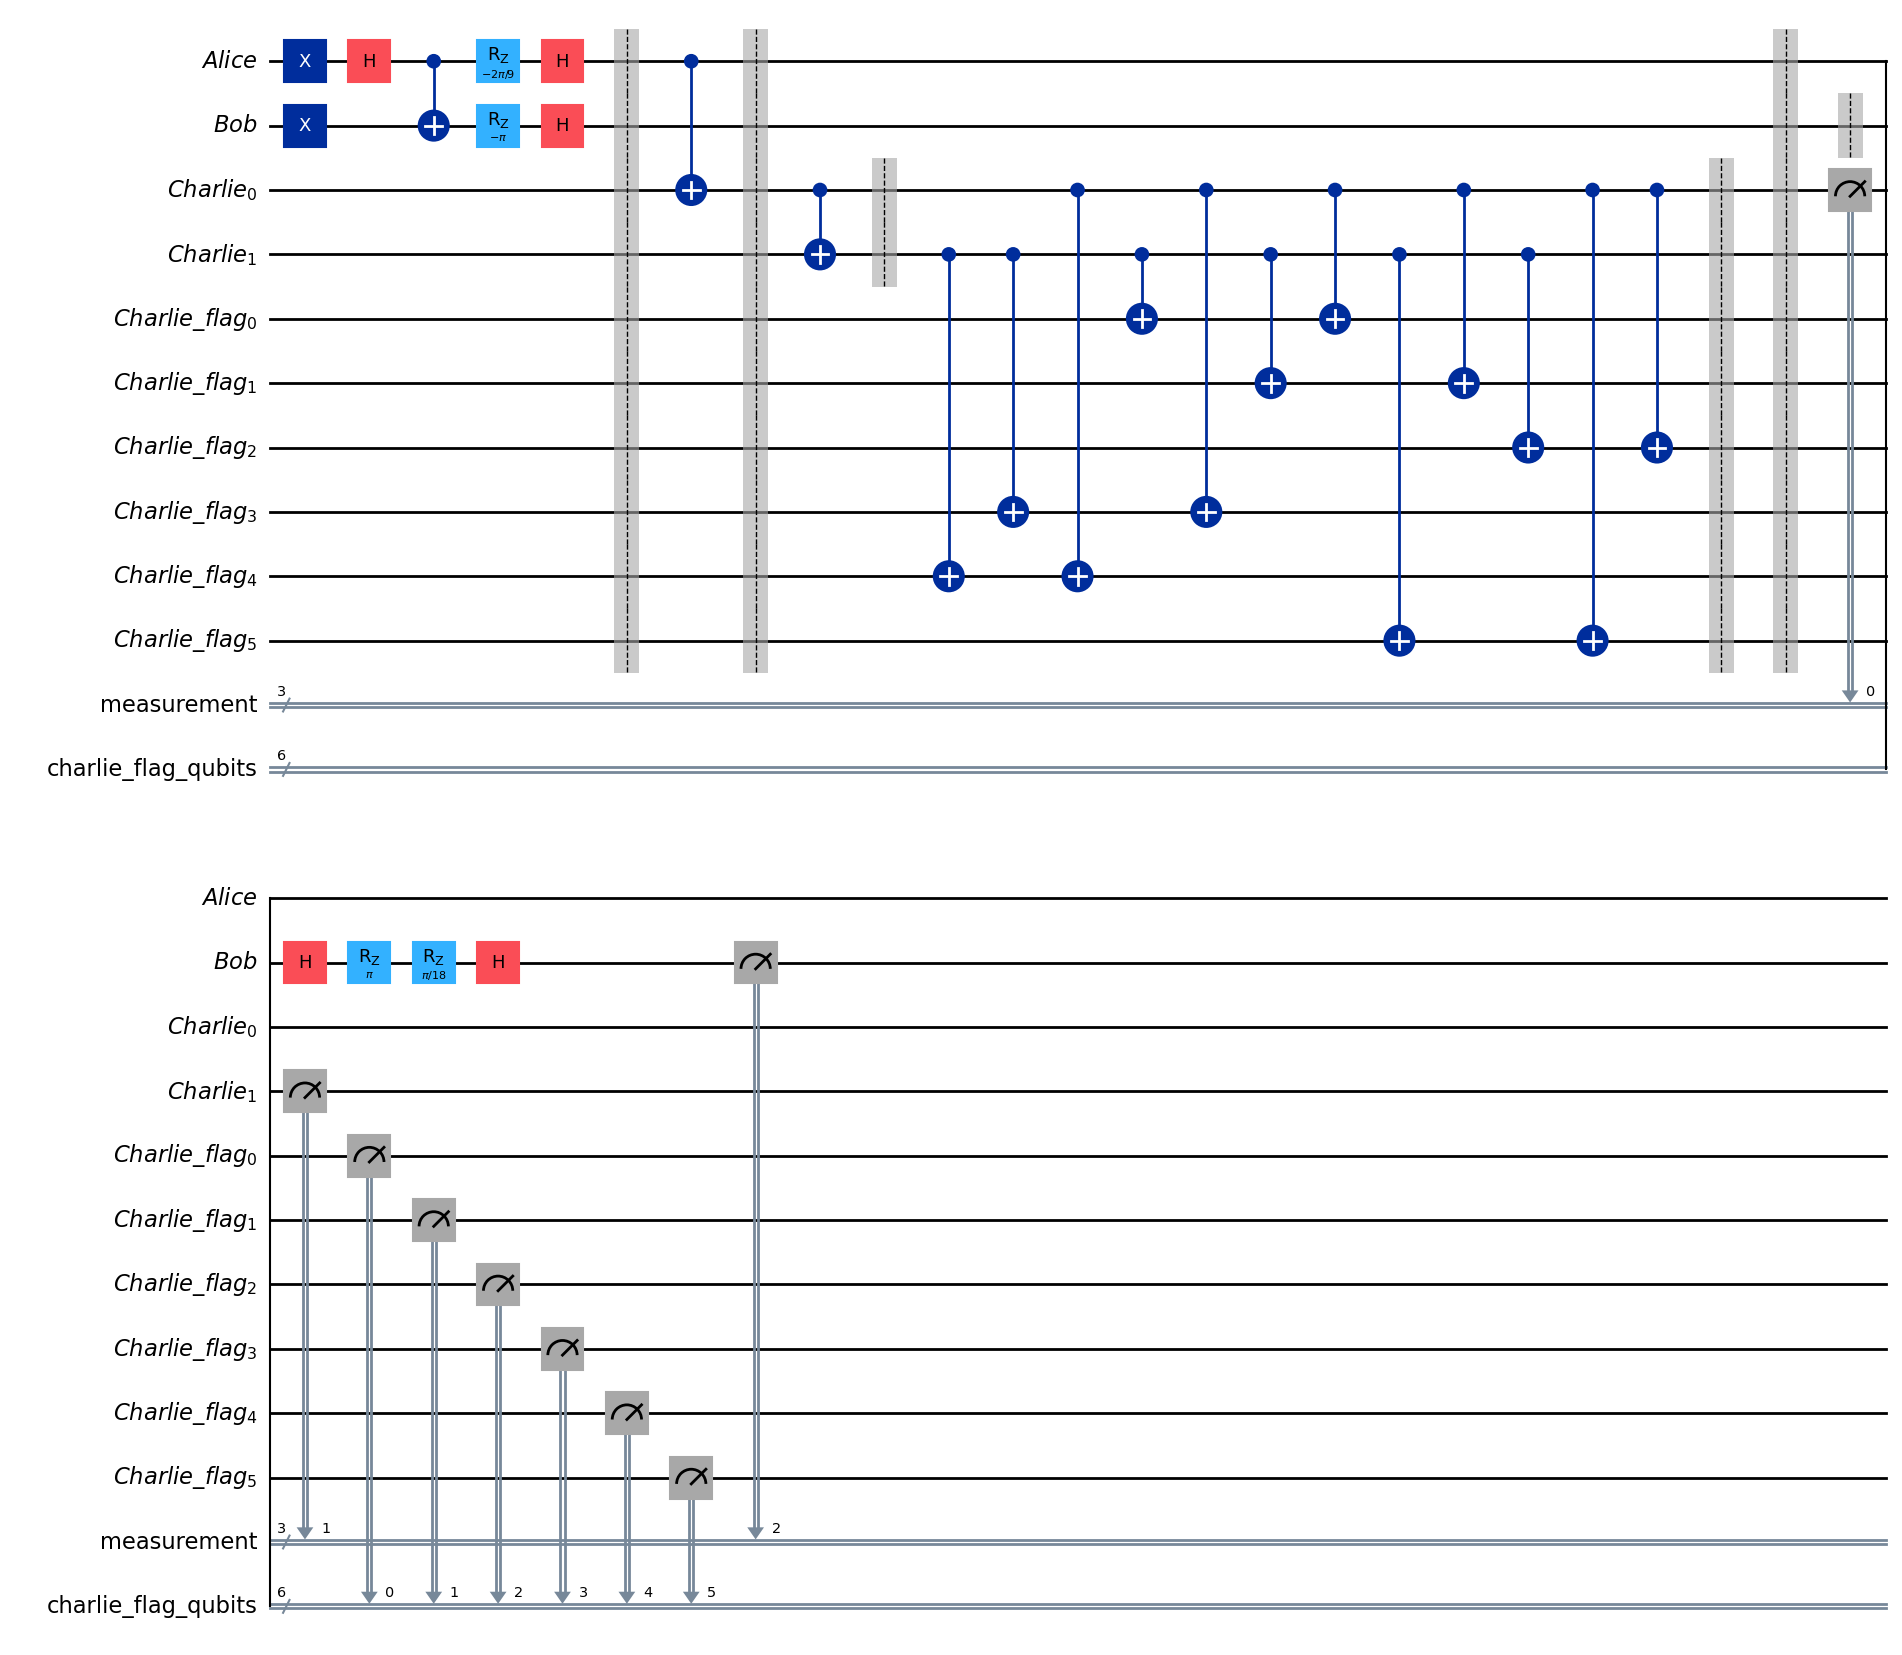

In [52]:
alice_setting = PEEK
bob_setting = REVERSE_1
charlie_size = 2
debbie_size = 0
strategy = MAJORITY_VOTE

ewfs = EWFS(
    alice_setting=alice_setting,
    bob_setting=bob_setting,
    strategy=strategy,
    charlie_size=charlie_size,
    debbie_size=debbie_size,
    friend_state="ghz",
)
qc = ewfs.circuit()
qc.draw("mpl", style="default")

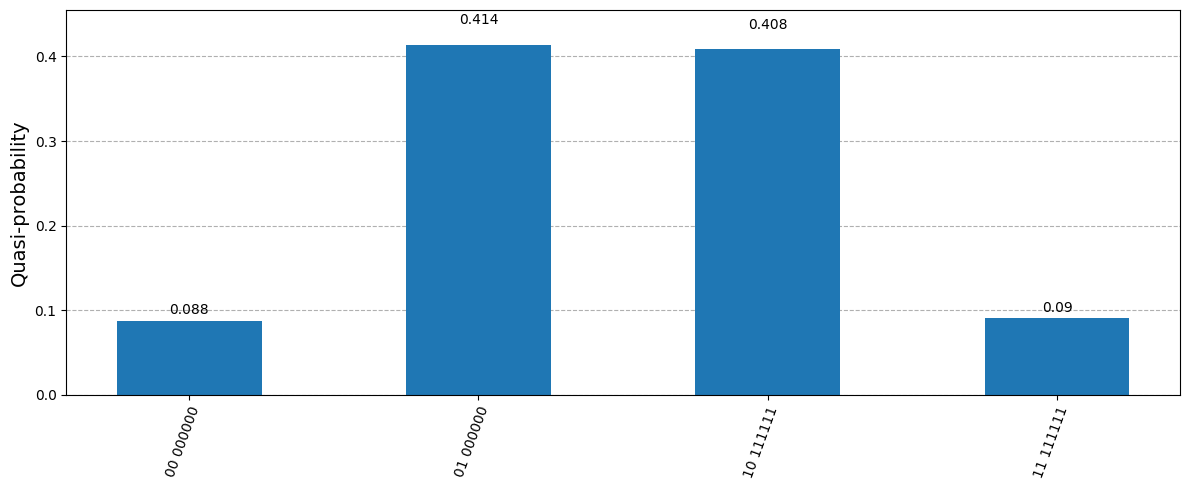

In [5]:
# lots of noise
noise_model = depolarizing_model(circ=qc, single_qubit_error_rate=0.001, two_qubit_error_rate=0.01, meas_error_rate=0.01)
# Create noisy simulator backend
sim_noise = AerSimulator(noise_model=None)

shots = 10_000
job = sim_noise.run(qc, shots=shots)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / shots for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

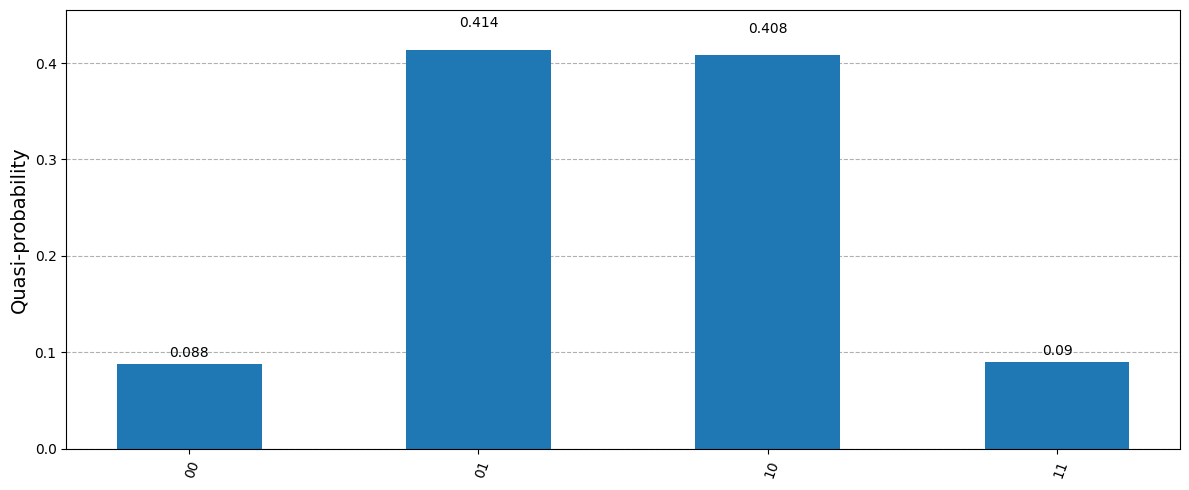

In [ ]:
results = {(alice_setting, bob_setting): probabilities}
post_selected_results = post_select_results(results, charlie_size, debbie_size, 6, 0)
dec_res = decode_results(post_selected_results, charlie_size=charlie_size, debbie_size=debbie_size)
probs = dec_res[(alice_setting, bob_setting)]

plot_distribution(probs, figsize=(12, 5))

In [5]:
results

{('peek', 'reverse_1'): {'111  000000': 0.0853,
  '001  000000': 0.4093,
  '000  000000': 0.0959,
  '110  000000': 0.4095}}

/Users/farrokhlabib/Documents/github/wigners_friend/.venv/lib/python3.12/site-packages/qiskit/visualization/circuit/matplotlib.py:270: UserWarning: Style JSON file 'default.json' not found in any of these locations: /Users/farrokhlabib/Documents/github/wigners_friend/.venv/lib/python3.12/site-packages/qiskit/visualization/circuit/styles/default.json, default.json. Will use default style.
  self._style, def_font_ratio = load_style(


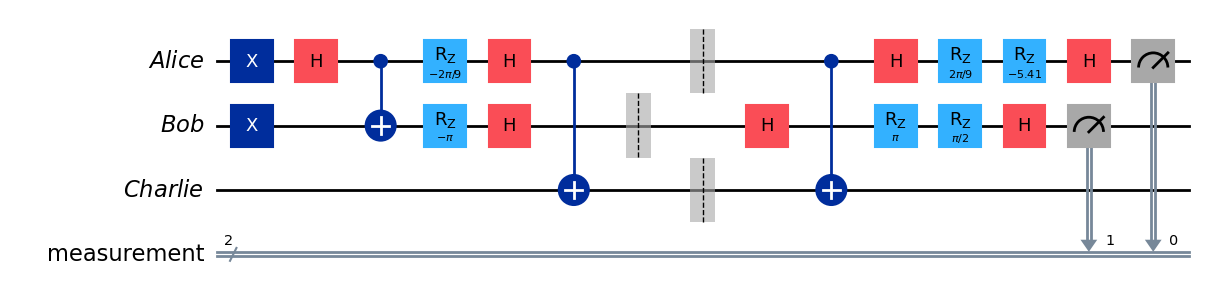

In [55]:
alice_setting = REVERSE_2
bob_setting = REVERSE_2
charlie_size = 1
debbie_size = 0
strategy = MAJORITY_VOTE


# Now using the cnot_ladder approach
ewfs = EWFS(
    alice_setting=alice_setting,
    bob_setting=bob_setting,
    strategy=strategy,
    charlie_size=charlie_size,
    debbie_size=debbie_size,
    friend_state="cnot_ladder",
)
qc = ewfs.circuit()
qc.draw("mpl", style="default")

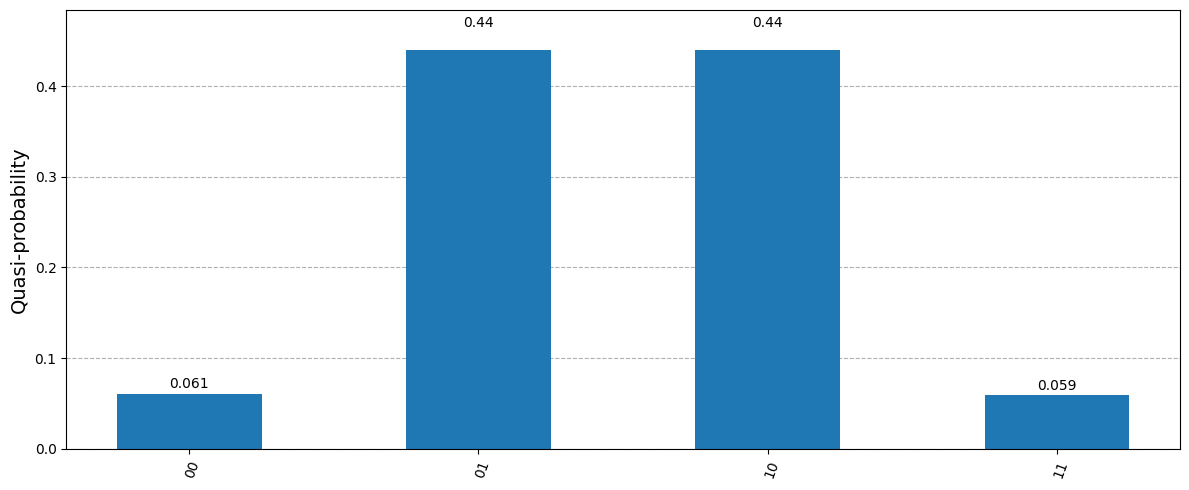

In [56]:
# Create noisy simulator backend
sim_noise = AerSimulator(noise_model=None)

shots = 10_000
job = sim_noise.run(qc, shots=shots)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / shots for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

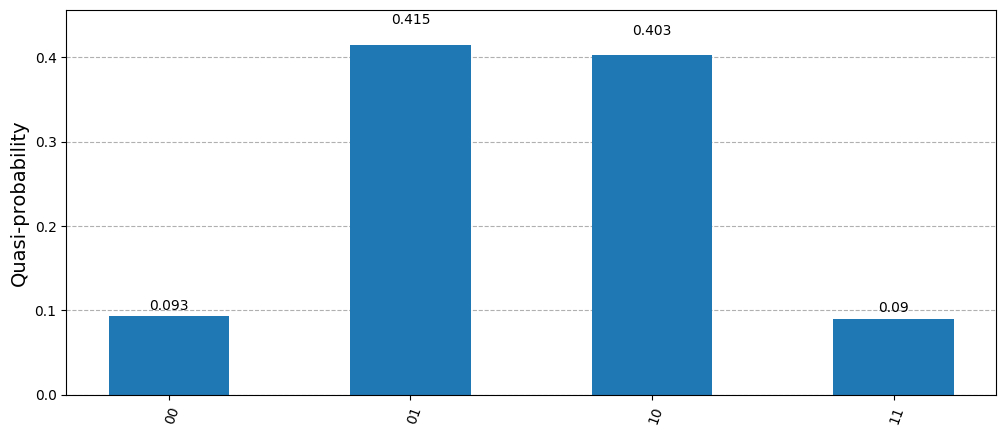

In [8]:
results = {(alice_setting, bob_setting): probabilities}
dec_res = decode_results(results, charlie_size=charlie_size, debbie_size=debbie_size)
probs = dec_res[(alice_setting, bob_setting)]
plot_distribution(probs, figsize=(12, 5))

## Experiment

Run EWFS experiment for a specific number of shots, trials, and over a range of friend sizes.

#### Settings

In [9]:
from ewfs import run_experiment, SEMI_BRUKNER_SETTINGS

run_experiment(settings=SEMI_BRUKNER_SETTINGS, strategy="random")

Trial 1 out of 2 for task of 1_1
Task with task ID: fbc5c6c3-f659-4351-b9cb-3710ca809bb7

Trial 2 out of 2 for task of 1_1
Task with task ID: c9cfca5a-0503-4d57-9be4-7a81a48e7646

Trial 1 out of 2 for task of 2_1
Task with task ID: 8ba54b6f-2031-49ee-867d-e06589eecec7

Trial 2 out of 2 for task of 2_1
Task with task ID: 4a08c30d-7bb2-4d26-b272-80a3f12bc0fd

Processing trial 1 for task with task ID: fbc5c6c3-f659-4351-b9cb-3710ca809bb7
Results: {('peek', 'reverse_1'): {'00': 0.0921, '10': 0.4118, '01': 0.4087, '11': 0.0874}, ('peek', 'reverse_2'): {'11': 0.4084, '00': 0.4089, '10': 0.0916, '01': 0.0911}, ('reverse_2', 'reverse_1'): {'10': 0.4378, '11': 0.0622, '01': 0.4417, '00': 0.0583}, ('reverse_2', 'reverse_2'): {'10': 0.4428, '01': 0.4465, '11': 0.0549, '00': 0.0558}}
semi_brukner=0.8131999999999997 -- is violated: True
Violations: {'semi_brukner': 0.8131999999999997}

Post-processed results: defaultdict(<function run_experiment.<locals>.<lambda> at 0x14c090e00>, {'1_1': defaultdic

defaultdict(<function ewfs.experiment.run_experiment.<locals>.<lambda>()>,
            {'1_1': defaultdict(list,
                         {'semi_brukner': [0.8131999999999997,
                           0.7976000000000001]}),
             '2_1': defaultdict(list,
                         {'semi_brukner': [0.8196000000000003,
                           0.8074000000000003]})})